# EDA

## Import lib

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Import dataset

In [2]:
df = pd.read_pickle('../data/cleaned-data/cleaned.pkl')

In [3]:
df.sample()

,order-id,order-date,ship-date,ship-mode,customer-id,customer-name,segment,country,city,state,postal-code,region,product-id,category,sub-category,product-name,sales,quantity,discount,profit
274,CA-2017-118136,2017-09-16,2017-09-17,First Class,BB-10990,Barry Blumstein,Corporate,United States,Inglewood,California,90301,West,OFF-PA-10002615,Office Supplies,Paper,"Ampad Gold Fibre Wirebound Steno Books, 6"" x 9...",8.82,2,0.0,4.0572


In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 9993 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order-id       9993 non-null   str           
 1   order-date     9993 non-null   datetime64[us]
 2   ship-date      9993 non-null   datetime64[us]
 3   ship-mode      9993 non-null   category      
 4   customer-id    9993 non-null   str           
 5   customer-name  9993 non-null   str           
 6   segment        9993 non-null   category      
 7   country        9993 non-null   str           
 8   city           9993 non-null   str           
 9   state          9993 non-null   category      
 10  postal-code    9993 non-null   str           
 11  region         9993 non-null   category      
 12  product-id     9993 non-null   str           
 13  category       9993 non-null   category      
 14  sub-category   9993 non-null   category      
 15  product-name   9993 non-null   str   

## Categorise columns
**Numerical**:
- sales  
- quantity
- discount  
- profit  

**Categorical**
- ship-mode
- segment
- state
- region
- category
- sub-category

## Univariate Analysis

### On Numerical columns

#### `sales`

In [5]:
df['sales'].describe()

count     9993.000000
mean       229.852846
std        623.276074
min          0.444000
25%         17.280000
50%         54.480000
75%        209.940000
max      22638.480000
Name: sales, dtype: float64

<Axes: xlabel='sales', ylabel='Count'>

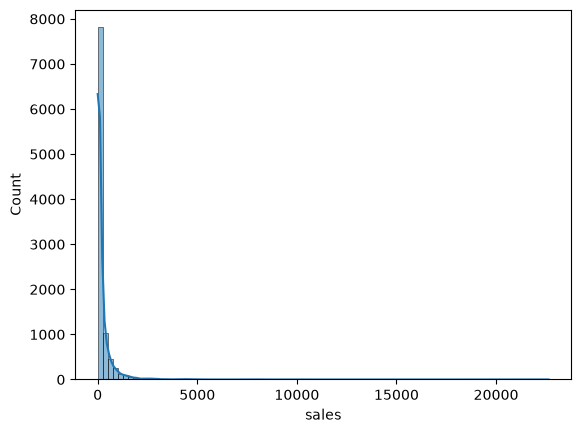

In [6]:
# To know the distribution of sales data
sns.histplot(data=df, x='sales', bins=90, kde=True)

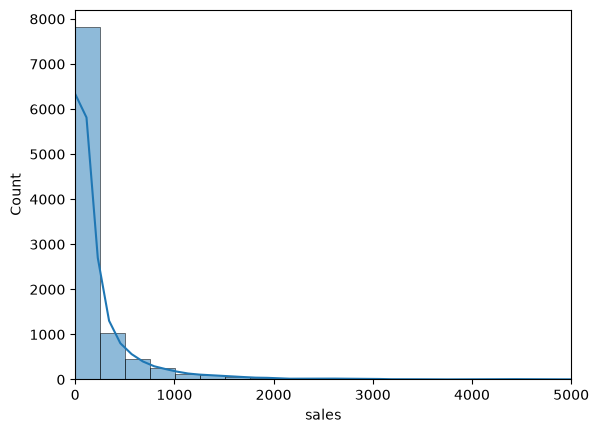

In [7]:
sns.histplot(data=df, x='sales', bins=90, kde=True)
plt.xlim(0,5000)
plt.show()

<Axes: xlabel='sales', ylabel='Density'>

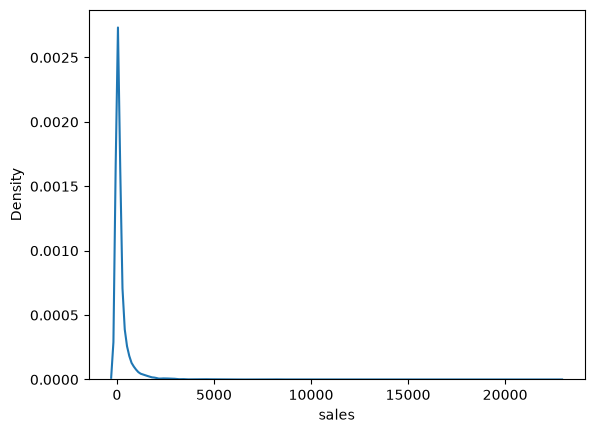

In [8]:
sns.kdeplot(data=df, x='sales')

<Axes: xlabel='sales'>

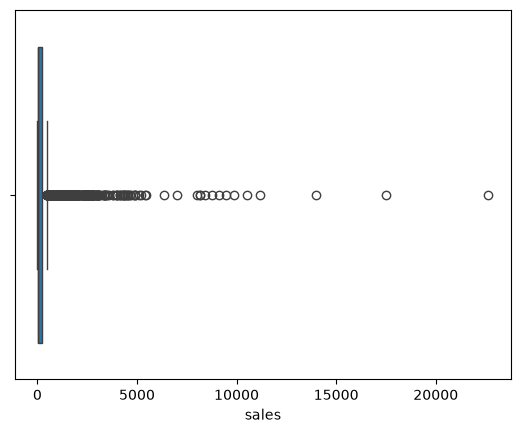

In [9]:
sns.boxplot(data=df, x='sales')

*By using above results of describe(), hist, kde and box plots.*  
- General observation  
*The sales data is highly right skewed and the 75% of the data is below 209.94*  
*The tail is very long from the median where median is 54.48 the largest value is 22638*  
*The box plot shows that there are large amount of outliers which shows that large amount of data is is of small values*  
- Business observation  
*Majory sales are below 209.94\$ around 75% sales specifically and there only 25% of sales are have crossed 209.94\\$ mark*
-----------

#### `quantity`

In [10]:
df.quantity.describe()

count    9993.000000
mean        3.789753
std         2.225149
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        14.000000
Name: quantity, dtype: float64

<Axes: xlabel='quantity', ylabel='Count'>

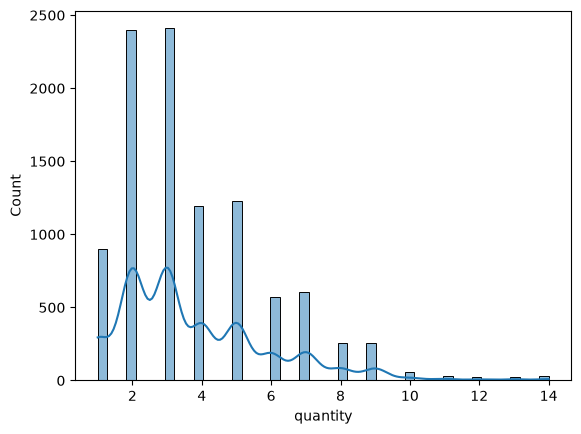

In [11]:
sns.histplot(data=df, x='quantity', kde=True)

<Axes: xlabel='quantity'>

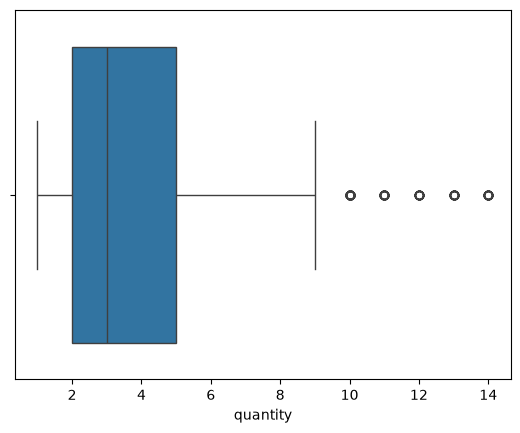

In [12]:
sns.boxplot(data=df, x='quantity')

**Observations:**  
- *The 75\% of the orders are ordering the at most 5 quantity of the product.* (The orders have different records for each product so 75\% of customes order product with at most 5 quantity)
- *The quantity data is also right skewed where the majority of the orders have quantity of 1 to 5, where max quantity is of 14*

#### `discount`

In [13]:
df.discount.describe()

count    9993.000000
mean        0.156188
std         0.206457
min         0.000000
25%         0.000000
50%         0.200000
75%         0.200000
max         0.800000
Name: discount, dtype: float64

<Axes: xlabel='discount', ylabel='Count'>

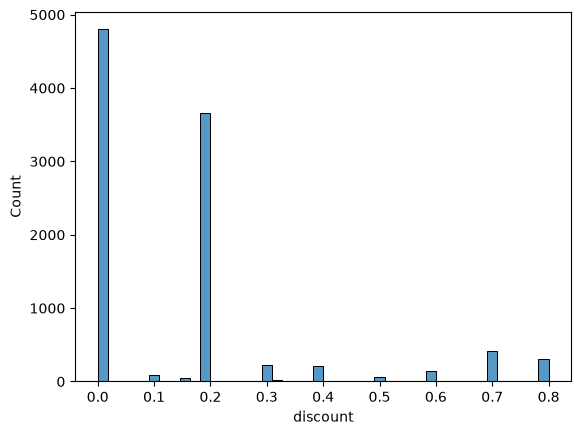

In [14]:
sns.histplot(data=df, x='discount')

<Axes: xlabel='discount'>

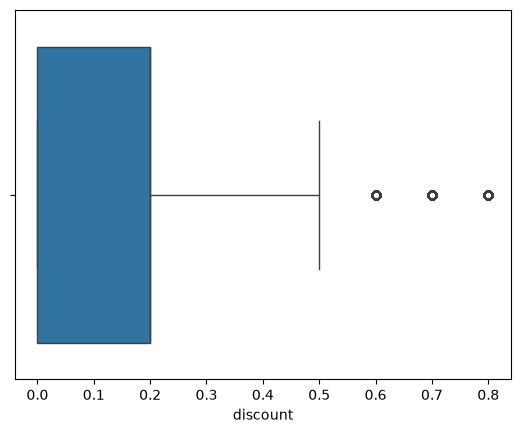

In [15]:
sns.boxplot(data=df, x='discount')

**Observations**  
- *The discount is largely given 0 or 20%*
- *25% sales are without any discount*  
- *There are very few discount given more than 20% but some given 70% & 80% also.*

#### `profit`

In [16]:
df['profit'].describe()

count    9993.000000
mean       28.660971
std       234.271476
min     -6599.978000
25%         1.731000
50%         8.671000
75%        29.364000
max      8399.976000
Name: profit, dtype: float64

<Axes: xlabel='profit', ylabel='Count'>

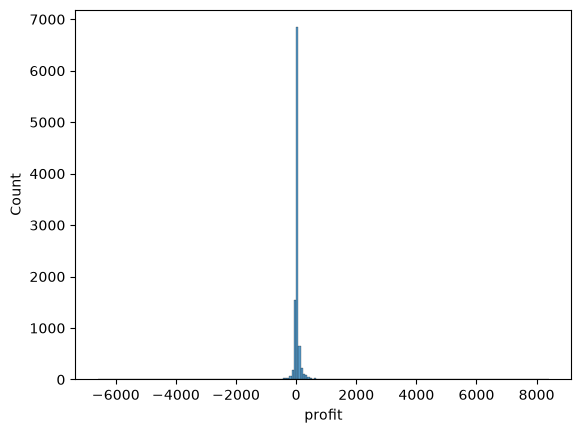

In [17]:
sns.histplot(data=df, x='profit')

(-500.0, 500.0)

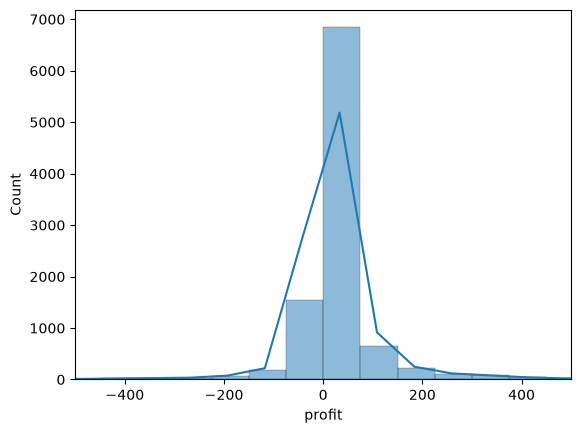

In [18]:
sns.histplot(data=df, x='profit', kde=True)
plt.xlim(-500, 500)

<Axes: xlabel='profit'>

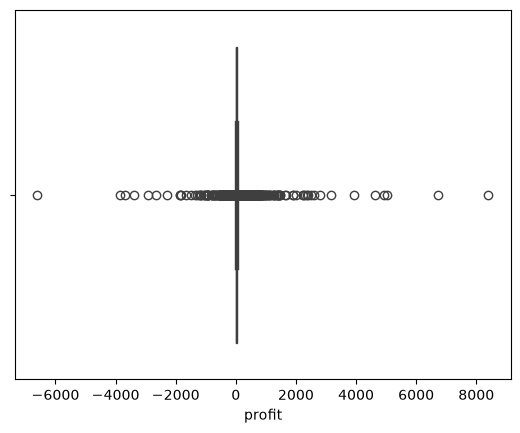

In [19]:
sns.boxplot(data=df, x='profit')

In [20]:
print("Number of orders made loss",df[df['profit']<0]['profit'].count())
print("Number of orders made profit",df[df['profit']>0]['profit'].count()) 
print("Number of orders did not made profit nor loss",df[df['profit']==0]['profit'].count()) 

Number of orders made loss 1870
Number of orders made profit 8058
Number of orders did not made profit nor loss 65


In [21]:
loss, profit, none = 1870, 8085, 65
total = loss + profit + none
percentofloss = (loss/total)*100
percentofprofit = (profit/total)*100
percentofnone = (none/total)*100
percentofloss, percentofprofit, percentofnone

(18.6626746506986, 80.688622754491, 0.6487025948103792)

**Observation:**  
- *The profit seems sharp peake at 0+*
- *The right tail is very long 8399 than left tail 6599*
- *There are more numbers of order which made profit than orders which made loss*
- *There are some orders which did not made profit bur also did not made loss (around 65 orders)*
- *Exact figures are Loss-18%, Profit-80% & 0.64% are nither profit nor loss*

### On categorical columns

#### `ship-mode`

In [22]:
df['ship-mode'].unique()

['Second Class', 'Standard Class', 'First Class', 'Same Day']
Categories (4, str): ['First Class', 'Same Day', 'Second Class', 'Standard Class']

In [23]:
df['ship-mode'].value_counts()

ship-mode
Standard Class    5967
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

In [24]:
labels =['Standard Class','Second Class','First Class','Same Day']

<Axes: xlabel='ship-mode', ylabel='count'>

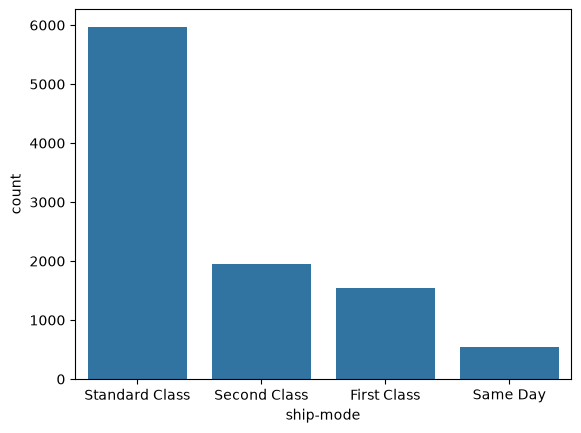

In [25]:
sns.countplot(data=df, x='ship-mode', order=labels)

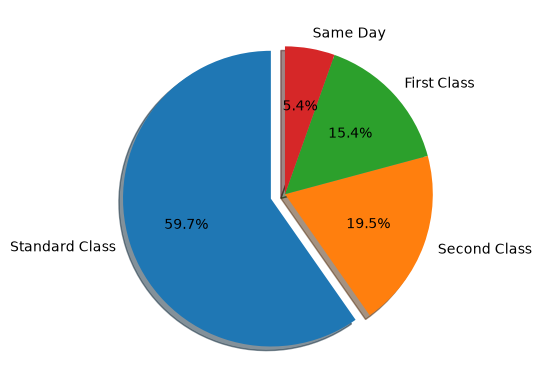

In [26]:
plt.pie(df['ship-mode'].value_counts(), labels=labels, autopct='%1.1f%%', explode=(0.1, 0, 0, 0), shadow=True, startangle=90)

**Observation:**  
- *There are mainly 4 options in the ship-mode Standard, Second, First and Same Day Class.*
- *The majority of the orders are in Standard Class bery few customer order the product on Same Day.*
- *The price of the Same Day Class is high so the users are less and Standard my have no price or minimal; price so it has majority of customer*
- *more than 50% of orders are Standard Class orders*
- *Standard Class-59.7%, Second class-19.5%, First Class-15.4% and Same Day-5.4%*
- *My personal suggection will be to decrease price of Second Class ship-mode it will definetly attract more customer to select Second Class* (The customers have 3 options second first or same day, the rich guy may choose same day, but the guy who is gonna order it in Standard Class can see the Second class price and the amount of customes choosing first and second are nearly same only 4% gap so by decreasing the Second class price it maybe possible that the some part of Standard will go to choose Second Class it may reduce first class customer little bit but the second class customer will increase)
----------

#### `segment`

In [27]:
df['segment'].unique()

['Consumer', 'Corporate', 'Home Office']
Categories (3, str): ['Consumer', 'Corporate', 'Home Office']

In [28]:
df['segment'].value_counts()

segment
Consumer       5191
Corporate      3020
Home Office    1782
Name: count, dtype: int64

<Axes: xlabel='segment', ylabel='count'>

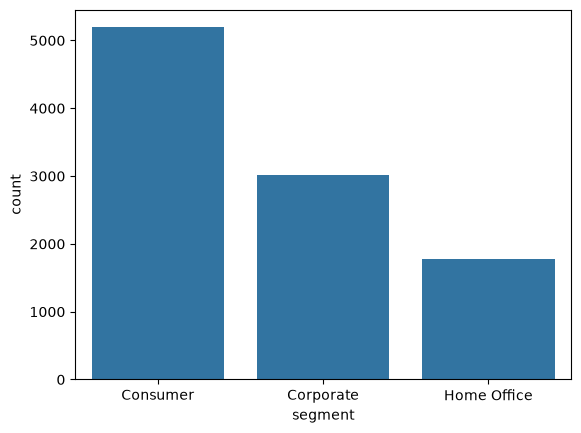

In [29]:
sns.countplot(data=df, x='segment')

In [30]:
labels = ['Consumer', 'Corporate segment', 'Home Office']

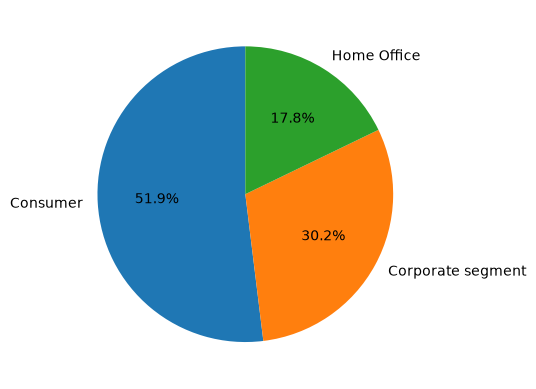

In [31]:
plt.pie(df['segment'].value_counts(), labels=labels, autopct='%1.1f%%', startangle=90)

**Observations:**  
- *There are three segments `Consumer`, `Corporate segment` and `Home Office`*
- *Almost half orders are by Consumers and other half are 30% from Corporate and 17 from Home Office*

#### `state`

In [32]:
df['state'].unique()

['Kentucky', 'California', 'Florida', 'North Carolina', 'Washington', ..., 'South Dakota', 'Idaho', 'North Dakota', 'Wyoming', 'West Virginia']
Length: 49
Categories (49, str): ['Alabama', 'Arizona', 'Arkansas', 'California', ..., 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']

In [33]:
df['state'].value_counts()

state
California              2001
New York                1128
Texas                    985
Pennsylvania             587
Washington               506
Illinois                 492
Ohio                     468
Florida                  383
Michigan                 255
North Carolina           249
Arizona                  224
Virginia                 224
Georgia                  184
Tennessee                183
Colorado                 182
Indiana                  149
Kentucky                 139
Massachusetts            135
New Jersey               130
Oregon                   124
Wisconsin                110
Maryland                 105
Delaware                  96
Minnesota                 89
Connecticut               82
Missouri                  66
Oklahoma                  66
Alabama                   61
Arkansas                  60
Rhode Island              56
Mississippi               53
Utah                      53
Louisiana                 42
South Carolina            42
Nevada  

In [34]:
labels = df['state'].value_counts().index

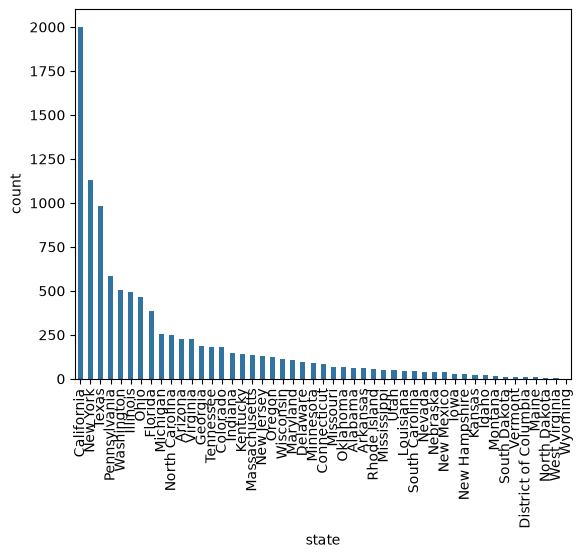

In [35]:
sns.countplot(data=df, x='state', order=labels, width=0.5)
plt.xticks(rotation=90, ha='center') 
plt.show()

**Observations:**
- *There are 49 states in total*
- *Big States have big amount of orders*

#### `region`

In [36]:
df['region'].unique()

['South', 'West', 'Central', 'East']
Categories (4, str): ['Central', 'East', 'South', 'West']

In [37]:
df['region'].value_counts()

region
West       3203
East       2847
Central    2323
South      1620
Name: count, dtype: int64

<Axes: xlabel='region', ylabel='count'>

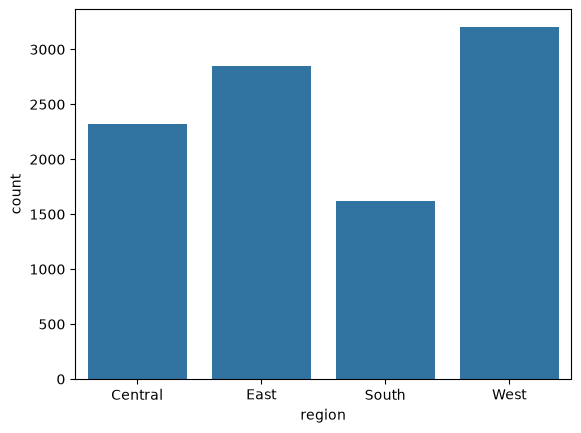

In [38]:
sns.countplot(data=df, x='region')

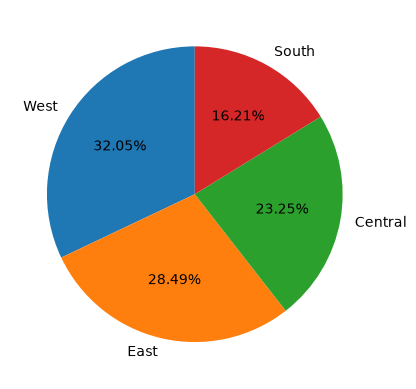

In [39]:
labels = df['region'].value_counts().index
plt.pie(df['region'].value_counts(), labels=labels, autopct='%1.2f%%', startangle=90)

**Observations:**  
- *The West region is having highest orders because one big city California*
- *The East side also have major cities like NY*
- *The central part of US have many city along with large one that is Texas*
- *the south part only have Florida as major city so the sales in south part is lowest*

#### `category`

In [40]:
df.category.unique()

['Furniture', 'Office Supplies', 'Technology']
Categories (3, str): ['Furniture', 'Office Supplies', 'Technology']

In [41]:
df['category'].value_counts()

category
Office Supplies    6026
Furniture          2120
Technology         1847
Name: count, dtype: int64

In [42]:
labels = df['category'].value_counts().index.to_list()

<Axes: xlabel='category', ylabel='count'>

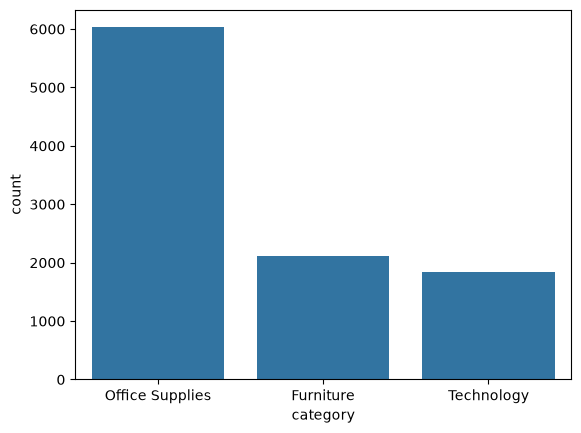

In [43]:
sns.countplot(data=df, x='category', order = labels)

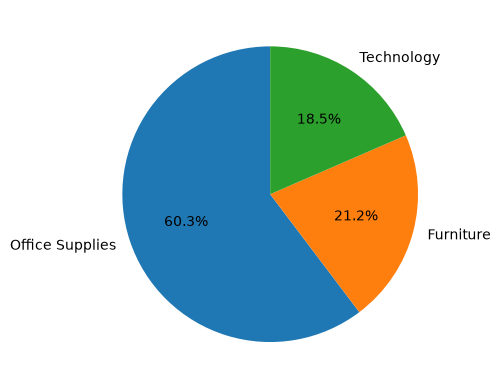

In [44]:
plt.pie(df['category'].value_counts(),labels=labels, autopct='%1.1f%%', startangle=90)

**Observations:**
- *The majority of orders are of category Office Supplies*
- *Office supplies-60%, Furniture-21% and Technology-18%*

#### `sub-category`

In [45]:
df['sub-category'].unique()

['Bookcases', 'Chairs', 'Labels', 'Tables', 'Storage', ..., 'Envelopes', 'Fasteners', 'Supplies', 'Machines', 'Copiers']
Length: 17
Categories (17, str): ['Accessories', 'Appliances', 'Art', 'Binders', ..., 'Phones', 'Storage', 'Supplies', 'Tables']

In [46]:
df['sub-category'].value_counts()

sub-category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          616
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64

In [47]:
labels = df['sub-category'].value_counts().index

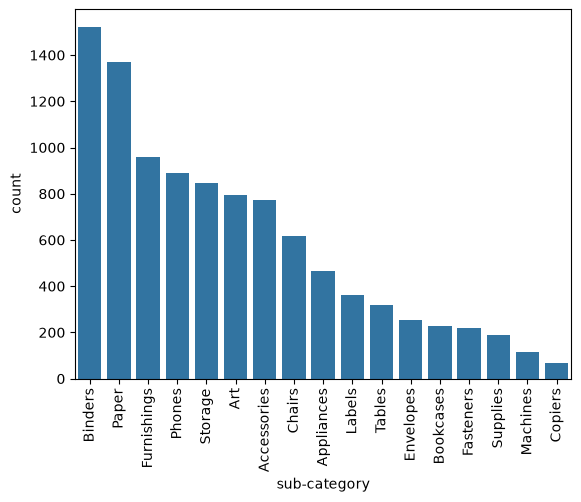

In [48]:
sns.countplot(data=df, x='sub-category', order=labels)
plt.xticks(rotation=90)
plt.show()

**Observations:**
- *The Sub category have 17 types*

## Bivariate Analysis

In [49]:
df.sample()

,order-id,order-date,ship-date,ship-mode,customer-id,customer-name,segment,country,city,state,postal-code,region,product-id,category,sub-category,product-name,sales,quantity,discount,profit
2115,CA-2015-164882,2015-10-31,2015-10-31,Same Day,SG-20080,Sandra Glassco,Consumer,United States,Redlands,California,92374,West,FUR-BO-10002213,Furniture,Bookcases,DMI Eclipse Executive Suite Bookcases,425.833,1,0.15,20.0392


### `profit` analysis with other features

#### `profit`-`ship-mode`

In [50]:
df['ship-mode'].value_counts()

ship-mode
Standard Class    5967
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

<Axes: ylabel='profit'>

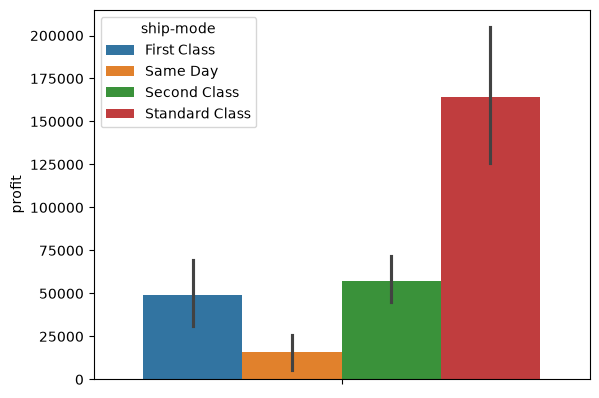

In [51]:
sns.barplot(data=df, y='profit', hue='ship-mode', estimator='sum')

In [52]:
df.groupby('ship-mode').agg(total_profit=('profit', 'sum'))

,total_profit
ship-mode,
First Class,48969.8399
Same Day,15891.7589
Second Class,57446.6354
Standard Class,164100.8463


**Observation:**
- *Nothing abnormal*
- *The Standard class have massive number of orders so its obvious that it will make most of the profit*
- *The First Class & Second Class behave same the second class little lead in number of orders and in profit also*
- *Same Day have lowest orders as well as lowest profit*
- *The single order of each class can have different profits cause the Same Day will be charged more with more profit in it and the standard will have lower profit than Same Day*

#### `profit`-`segment`

In [53]:
df['segment'].value_counts().reset_index().set_index('segment')

,count
segment,
Consumer,5191
Corporate,3020
Home Office,1782


<Axes: ylabel='profit'>

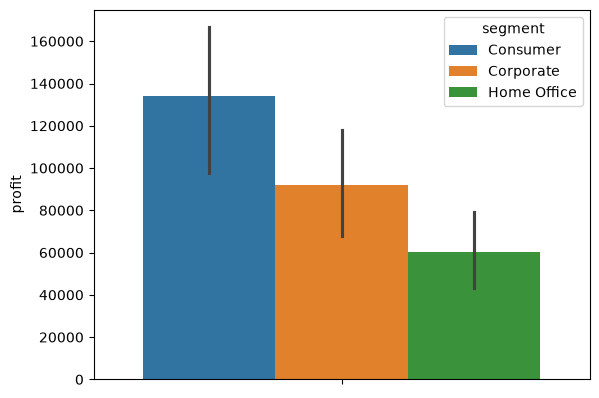

In [54]:
sns.barplot(data=df, y='profit', hue='segment', estimator='sum')

In [55]:
info = df.groupby('segment').agg(total_profit=('profit', 'sum'), count=('segment', 'count'))
info

,total_profit,count
segment,,
Consumer,134119.2092,5191
Corporate,91979.1340,3020
Home Office,60310.7373,1782


In [56]:
rate = (info['total_profit']/info['count']).reset_index()
rate

,segment,0
0,Consumer,25.836873
1,Corporate,30.456667
2,Home Office,33.844409


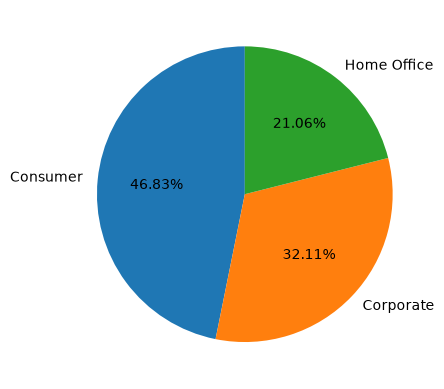

In [57]:
plt.pie(info['total_profit'], labels=info.index, autopct='%1.2f%%', startangle=90)

**Observations:**
- *The majority of the orders are from Consumer segment and corporate is in middle and the lowest sales are from Home Office*
- *The Total profit from each segment is directly proportional to the orders of that particulae segment*
- *But the average profit from an order tells different story*
- *The Home Office gives most profit 33.84, Corporate gives 30.45 and the lowest is from Consumer 25.83*
- *From total profit the 46.83% comes from Consumers, 32.11% from Corporate and the remaining 21% comes from Home office*

#### `profit`-`state`

In [58]:
info = df.groupby('state').agg(count=('state', 'count'), total_profit=('profit', 'sum'))
info

,count,total_profit
state,,
Alabama,61,5786.8253
Arizona,224,-3427.9246
Arkansas,60,4008.6871
California,2001,76381.3871
Colorado,182,-6527.8579
Connecticut,82,3511.4918
Delaware,96,9977.3748
District of Columbia,10,1059.5893
Florida,383,-3399.3017


In [59]:
average_profit_perOrder = (info['total_profit']/info['count']).reset_index()
average_profit_perOrder

,state,0
0,Alabama,94.865989
1,Arizona,-15.303235
2,Arkansas,66.811452
3,California,38.171608
4,Colorado,-35.867351
5,Connecticut,42.823071
6,Delaware,103.930988
7,District of Columbia,105.958930
8,Florida,-8.875461
9,Georgia,88.315453


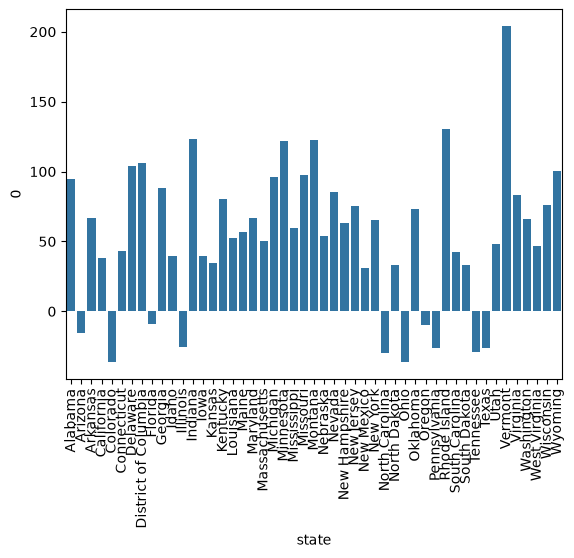

In [60]:
sns.barplot(data=average_profit_perOrder, x='state', y=0)
plt.xticks(rotation=90)
plt.show()

In [61]:
average_profit_perOrder.sort_values(by=0, ascending=False)

,state,0
43,Vermont,204.088936
37,Rhode Island,130.100523
12,Indiana,123.375411
24,Montana,122.221900
21,Minnesota,121.608847
7,District of Columbia,105.958930
6,Delaware,103.930988
48,Wyoming,100.196000
23,Missouri,97.518341
20,Michigan,95.934069


In [62]:
info['average_profit_perOrder'] = average_profit_perOrder.set_index('state')[0]

In [63]:
info.sort_values(by='average_profit_perOrder', ascending=False)

,count,total_profit,average_profit_perOrder
state,,,
Vermont,11,2244.9783,204.088936
Rhode Island,56,7285.6293,130.100523
Indiana,149,18382.9363,123.375411
Montana,15,1833.3285,122.221900
Minnesota,89,10823.1874,121.608847
District of Columbia,10,1059.5893,105.958930
Delaware,96,9977.3748,103.930988
Wyoming,1,100.1960,100.196000
Missouri,66,6436.2105,97.518341


**Observation:**
- *The different states have different average profit per order*
- *The Data is very different for different states*
- *The states in which the profit is in -ve that is the loss those cities have more orders except some cities like Californiya, NY, Washington, Virginia, Georgia and Michigan*

#### `profit`-`region`

In [64]:
profit_region = df.groupby('region')['profit'].agg(['count', 'sum'])
profit_region

,count,sum
region,,
Central,2323,39706.3625
East,2847,91534.8388
South,1620,46749.4303
West,3203,108418.4489


In [65]:
profit_region['avg_profit_perOrder'] = profit_region['sum']/profit_region['count']
profit_region

,count,sum,avg_profit_perOrder
region,,,
Central,2323,39706.3625,17.092709
East,2847,91534.8388,32.151331
South,1620,46749.4303,28.857673
West,3203,108418.4489,33.849032


**Observations:**
- *The central region have the least profit/order i.e. 17*
- *All other region have balanced profit/order on 30 average*
- *East-32, South-28 and West-33 profit/order*
- *The central part have significantly low profit/order as compare to other region cause it has decent amount of orders despite it has low profit/order*
- *West region have maximum orders and have maximum profit/order also*
- *The South region have less orders even though it has good profit/order 28.85*

#### `profit`-`category`

In [66]:
profit_category = df.groupby('category')['profit'].agg(['count', 'sum'])
profit_category

,count,sum
category,,
Furniture,2120,18463.3316
Office Supplies,6026,122490.8008
Technology,1847,145454.9481


In [67]:
profit_category['profit_perOrder'] = profit_category['sum']/profit_category['count']
profit_category

,count,sum,profit_perOrder
category,,,
Furniture,2120,18463.3316,8.709119
Office Supplies,6026,122490.8008,20.327050
Technology,1847,145454.9481,78.752002


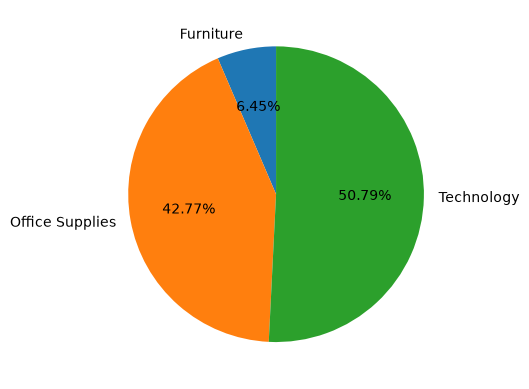

In [68]:
plt.pie(profit_category['sum'], autopct='%1.2f%%', startangle=90, labels=profit_category.index)

**Observations:**
- *Amoung the categories of product the Technology category is the most profitable with 50% of total profit comes from tech and have maximum profit/order also*
- *The Furniture has the least profit 6.45% as well as profit/order 8.7*
- *The more the orders lower the profit/order but here the furniture has below expected profit/order*
- *Office supplies are ordered the most and it has 20 profit/order*
- *From total profit the half is from tech, 42% from Office Supplies and rmaining 6.45 from Furniture*

#### `profit`-`sub-category`

In [69]:
profit_subcategory = df.groupby('sub-category')['profit'].agg(['count', 'sum'])
profit_subcategory

,count,sum
sub-category,,
Accessories,775,41936.6357
Appliances,466,18138.0054
Art,796,6527.7870
Binders,1523,30221.7633
Bookcases,228,-3472.5560
Chairs,616,26602.2251
Copiers,68,55617.8249
Envelopes,254,6964.1767
Fasteners,217,949.5182


In [70]:
profit_subcategory['profit_perOrder'] = profit_subcategory['sum'] / profit_subcategory['count']
profit_subcategory

,count,sum,profit_perOrder
sub-category,,,
Accessories,775,41936.6357,54.111788
Appliances,466,18138.0054,38.922758
Art,796,6527.7870,8.200737
Binders,1523,30221.7633,19.843574
Bookcases,228,-3472.5560,-15.230509
Chairs,616,26602.2251,43.185430
Copiers,68,55617.8249,817.909190
Envelopes,254,6964.1767,27.418019
Fasteners,217,949.5182,4.375660


In [71]:
cat_subcat = df.groupby('category')['sub-category'].unique().reset_index().set_index('category')
cat_subcat

,sub-category
category,
Furniture,"['Bookcases', 'Chairs', 'Tables', 'Furnishings..."
Office Supplies,"['Labels', 'Storage', 'Art', 'Binders', 'Appli..."
Technology,"['Phones', 'Accessories', 'Machines', 'Copiers..."


In [72]:
def findCategory(sub_category):
    if sub_category in ['Bookcases', 'Chairs', 'Tables', 'Furnishings']:
        return 'Furniture'
    elif sub_category in ['Labels', 'Storage', 'Art', 'Binders', 'Appliances', 'Paper', 'Envelopes', 'Fasteners', 'Supplies']:
        return 'Office_Supplies'
    else:
        return 'Technology'

In [73]:
profit_subcategory.reset_index()['sub-category'].apply(findCategory)

0          Technology
1     Office_Supplies
2     Office_Supplies
3     Office_Supplies
4           Furniture
5           Furniture
6          Technology
7     Office_Supplies
8     Office_Supplies
9           Furniture
10    Office_Supplies
11         Technology
12    Office_Supplies
13         Technology
14    Office_Supplies
15    Office_Supplies
16          Furniture
Name: sub-category, dtype: str

In [74]:
profit_subcategory['category'] = profit_subcategory.reset_index()['sub-category'].apply(findCategory).values

In [75]:
profit_subcategory

,count,sum,profit_perOrder,category
sub-category,,,,
Accessories,775,41936.6357,54.111788,Technology
Appliances,466,18138.0054,38.922758,Office_Supplies
Art,796,6527.7870,8.200737,Office_Supplies
Binders,1523,30221.7633,19.843574,Office_Supplies
Bookcases,228,-3472.5560,-15.230509,Furniture
Chairs,616,26602.2251,43.185430,Furniture
Copiers,68,55617.8249,817.909190,Technology
Envelopes,254,6964.1767,27.418019,Office_Supplies
Fasteners,217,949.5182,4.375660,Office_Supplies


In [76]:
profit_subcategory.sort_values(by='profit_perOrder', ascending=False)

,count,sum,profit_perOrder,category
sub-category,,,,
Copiers,68,55617.8249,817.909190,Technology
Accessories,775,41936.6357,54.111788,Technology
Phones,889,44515.7306,50.073938,Technology
Chairs,616,26602.2251,43.185430,Furniture
Appliances,466,18138.0054,38.922758,Office_Supplies
Machines,115,3384.7569,29.432669,Technology
Envelopes,254,6964.1767,27.418019,Office_Supplies
Storage,846,21278.8264,25.152277,Office_Supplies
Paper,1370,34053.5693,24.856620,Office_Supplies


**Observations:**
- *For sub-categories which are from Technology has higher profit/order, ofcourse cause the technology has highest profit/order among all categories*
- *There are 2 subcategories of Furniture have -ve profit/order same kind of thing we noticed in previous analysis the furniture makes loss*
- *But there are Chairs from Furniture category which making profit and it is significantly higher than all others (43 profit/order)*
- *All other things are normal, lots of numbers actually but all are okay as profit-category analysis*

#### `profit`-`quantity`

In [77]:
profit_quantity = df.groupby('quantity')['profit'].agg(['count','sum'])
profit_quantity

,count,sum
quantity,,
1,899,7440.4801
2,2401,38460.4676
3,2409,57015.5250
4,1191,44223.3908
5,1230,49516.5945
6,572,10325.4678
7,606,34286.9730
8,257,10856.7960
9,258,17687.8908


In [78]:
profit_quantity['profit_perOrder'] = profit_quantity['sum'] / profit_quantity['count']
profit_quantity.sort_values(by='profit_perOrder', ascending=False)

,count,sum,profit_perOrder
quantity,,,
13,27,6348.9010,235.144481
11,34,4293.3671,126.275503
14,29,2724.0038,93.931166
9,258,17687.8908,68.557716
7,606,34286.9730,56.579163
12,23,1185.0660,51.524609
8,257,10856.7960,42.244342
5,1230,49516.5945,40.257394
4,1191,44223.3908,37.131310


<Axes: xlabel='quantity', ylabel='profit_perOrder'>

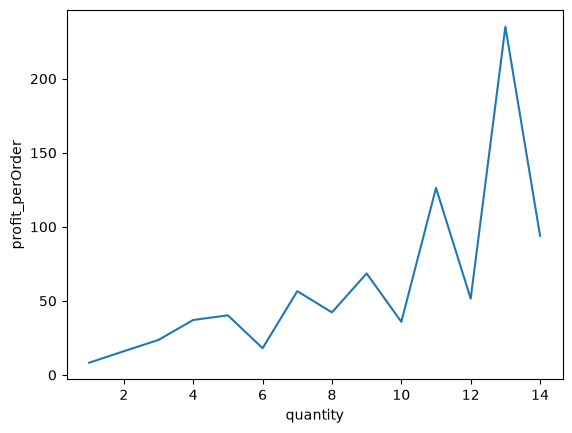

In [79]:
sns.lineplot(data = profit_quantity, x=profit_quantity.index, y='profit_perOrder')

**Observations:**
- *The more the quantity the more the profit! Thats it in this*
- *The quantity 10 has strange profit/order*
- *The trend is like 10 has low, 11 has high, 12 has low, 13 has high and 14 has low profit/order a intresting zigzag pattern*

#### `profit`-`discount`

In [80]:
profit_discount = df.groupby('discount')['profit'].agg(['count', 'sum', 'mean'])
profit_discount

,count,sum,mean
discount,,,
0.00,4798,320987.6032,66.900292
0.10,94,9029.1770,96.055074
0.15,52,1418.9915,27.288298
0.20,3657,90337.3060,24.702572
0.30,226,-10357.2186,-45.828401
0.32,27,-2391.1377,-88.560656
0.40,206,-23057.0504,-111.927429
0.45,11,-2493.1111,-226.646464
0.50,66,-20506.4281,-310.703456


<Axes: xlabel='discount', ylabel='mean'>

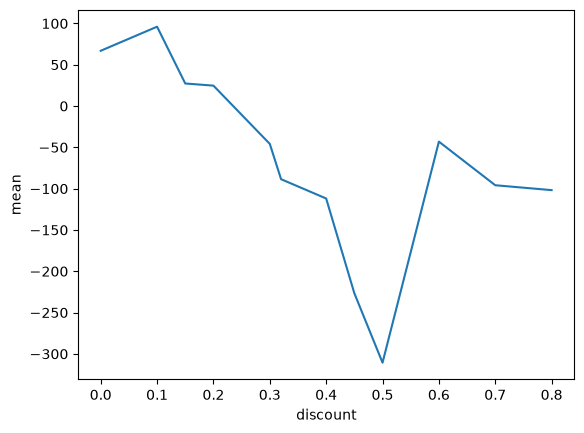

In [81]:
sns.lineplot(data=profit_discount, x=profit_discount.index, y='mean')

<Axes: xlabel='discount', ylabel='sum'>

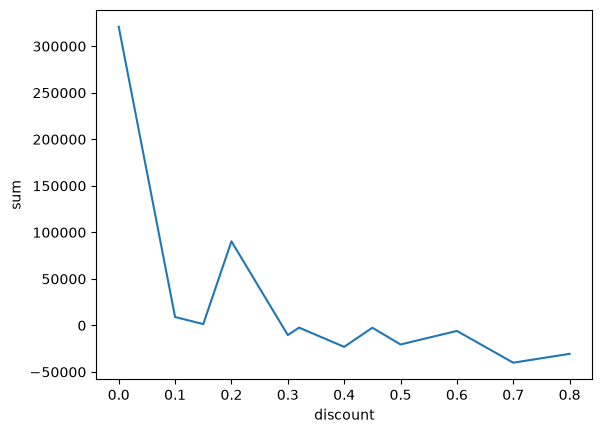

In [82]:
sns.lineplot(data=profit_discount, x=profit_discount.index, y='sum')

**Observations:**
- *Less the discount higher the profit!!*
- *Only the deals with less than 30% discount are making profit*
- *There are more orders which have less discount so the company is profitable*
- *The highest loss recorded at the 40 to 50% discount*

#### `profit`-`sales`

<Axes: xlabel='profit', ylabel='sales'>

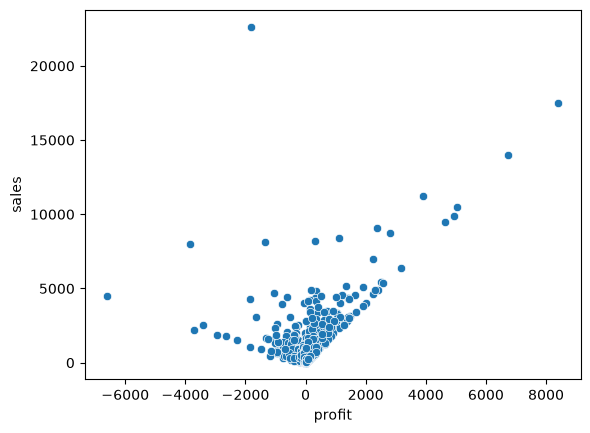

In [83]:
sns.scatterplot(data=df, x='profit', y='sales')

### Some other analysis

#### `discount`-`category`

In [84]:
pd.crosstab(df['discount'], df['category'])

category,Furniture,Office Supplies,Technology
discount,,,
0.00,836,3129,833
0.10,76,16,2
0.15,52,0,0
0.20,615,2201,841
0.30,221,0,5
0.32,27,0,0
0.40,75,0,131
0.45,11,0,0
0.50,54,0,12


**Observations:**
- *The Furniture category get more discount compare to other categories*

## Multivariate Analysis

In [85]:
df.sample()

,order-id,order-date,ship-date,ship-mode,customer-id,customer-name,segment,country,city,state,postal-code,region,product-id,category,sub-category,product-name,sales,quantity,discount,profit
6535,CA-2014-128209,2014-11-17,2014-11-22,Standard Class,GT-14710,Greg Tran,Consumer,United States,Buffalo,New York,14215,East,FUR-BO-10002213,Furniture,Bookcases,DMI Eclipse Executive Suite Bookcases,4007.84,10,0.2,-50.098


### `discount`-`profit`-`category`

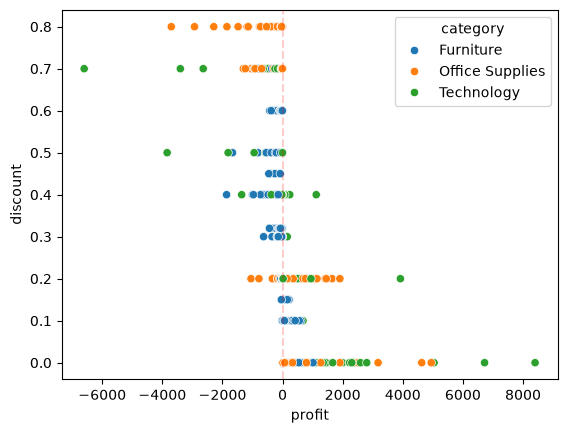

In [86]:
sns.scatterplot(data=df, x='profit', y='discount', hue='category')
plt.axvline(0, color='red', linestyle='--', alpha=0.2) 

In [87]:
df.groupby('category').agg(count=('profit','count'), total_profit=('profit', 'sum'), profit_perOrder=('profit', 'mean'))

,count,total_profit,profit_perOrder
category,,,
Furniture,2120,18463.3316,8.709119
Office Supplies,6026,122490.8008,20.327050
Technology,1847,145454.9481,78.752002


In [88]:
furniture = df[df['category']=='Furniture']
office = df[df['category']=='Office Supplies']
tech = df[df['category']=='Technology']

In [89]:
print(f"Furniture \nPROFIT: {(furniture['profit'] >= 0).sum()}, LOSS: {(furniture['profit'] < 0).sum()}\n")
print(f"Office Supplies \nPROFIT: {(office['profit'] >= 0).sum()}, LOSS: {(office['profit'] < 0).sum()}\n")
print(f"Technology \nPROFIT: {(tech['profit'] >= 0).sum()}, LOSS: {(tech['profit'] < 0).sum()}\n")

Furniture 
PROFIT: 1407, LOSS: 713

Office Supplies 
PROFIT: 5140, LOSS: 886

Technology 
PROFIT: 1576, LOSS: 271



In [90]:
1407/(1407+712)*100, 713/(1407+713)*100, 5140/(5140+886)*100, 886/(5140+886)*100, 1576/(1576+271)*100, 271/(1576+271)*100

(66.39924492685229,
 33.632075471698116,
 85.29704613342184,
 14.702953866578161,
 85.32755820249052,
 14.672441797509475)

**Observations:**
- *The Furniture category makes less profit but most of the times it have the discount 10 to 60% and makes loss almost every time*
- *The profit and loss % are very different in Fruniture and tech & Office supplies*
- *The furniture category makes the 33% of deals in loss*
- *One more reason is the furniture have most of there deals with discount so it makes the loss it has very less orders with no discount to overcome the loss made*
- *The Technology and Office Supplies makes game simple these category also give discount even more than furniture but in these categories the more number of deals are did without any dscount or low discount so thay manage to overcome the loss made*
- *Office supplies gives 20 70 or 80% discount but it only make loss in 70 80% discount and makes profit in even 20% discount and more orders lies in 0 to 20% discount so this category makes overall profit*
- *Technology is also similar to Office Supplies*

### `sales`-`profit`-`category`

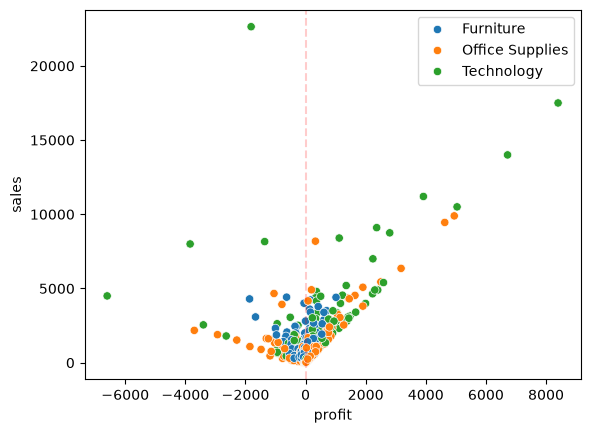

In [91]:
sns.scatterplot(data=df, x='profit', y='sales', hue='category')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.2)
plt.legend()

**Observations:**
- *The Furniture sales are concentrated at the zero which have little spread towards -ve side. Indeed it is in loss*
- *The Office Supplies have spread on both side so have profit and loss both but the spread to + have more also more dots to + so profitable*
- *The Technology which have the largest spread on both sides andit has low spread toward -vs side with lower orders than + so profitable*

### `sales`-`profit`-`discount`

<Axes: xlabel='sales', ylabel='discount'>

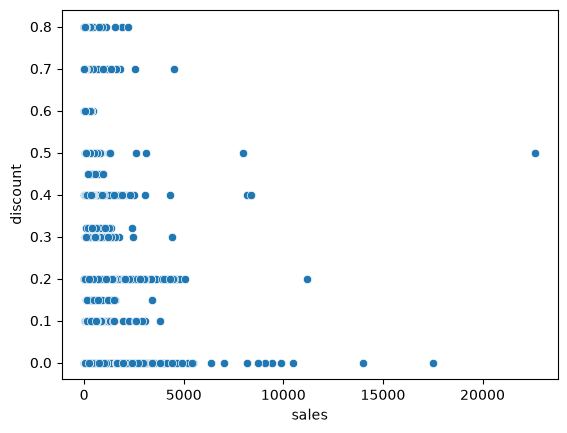

In [92]:
sns.scatterplot(data=df, x='sales', y='discount')

In [93]:
df.groupby('discount')['sales'].agg(['count', 'sum', 'mean'])

,count,sum,mean
discount,,,
0.00,4798,1.087908e+06,226.742074
0.10,94,5.436935e+04,578.397351
0.15,52,2.755852e+04,529.971567
0.20,3657,7.645944e+05,209.076940
0.30,226,1.029453e+05,455.510102
0.32,27,1.449346e+04,536.794770
0.40,206,1.164178e+05,565.134874
0.45,11,5.484974e+03,498.634000
0.50,66,5.891854e+04,892.705152


<Axes: xlabel='profit', ylabel='discount'>

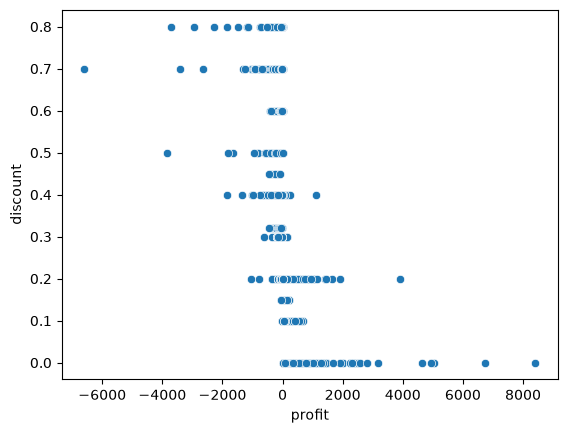

In [94]:
sns.scatterplot(data=df, x='profit', y='discount')

In [95]:
df.groupby('discount')['profit'].agg(['count', 'sum', 'mean'])

,count,sum,mean
discount,,,
0.00,4798,320987.6032,66.900292
0.10,94,9029.1770,96.055074
0.15,52,1418.9915,27.288298
0.20,3657,90337.3060,24.702572
0.30,226,-10357.2186,-45.828401
0.32,27,-2391.1377,-88.560656
0.40,206,-23057.0504,-111.927429
0.45,11,-2493.1111,-226.646464
0.50,66,-20506.4281,-310.703456


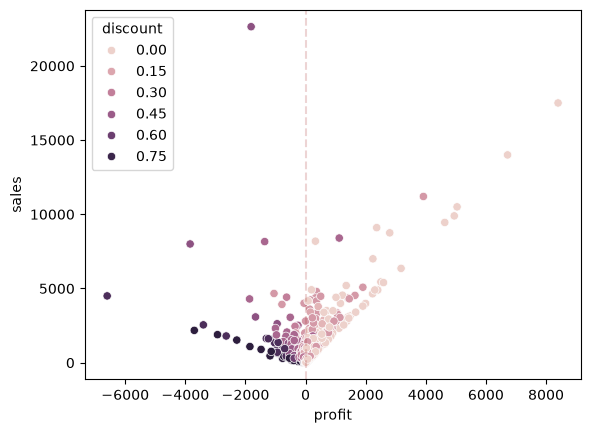

In [96]:
sns.scatterplot(data=df, x='profit', y='sales', hue='discount')
plt.axvline(color='brown', linestyle='--', alpha=0.2)

**Observations:**
- *We can see that the discount does not really affecting the customes to shop or order more and the more the discount the less the profit.*
- *low discount has more orders and more sales and more profit the larger the discount the less sales and less profit*

### `pairplot`

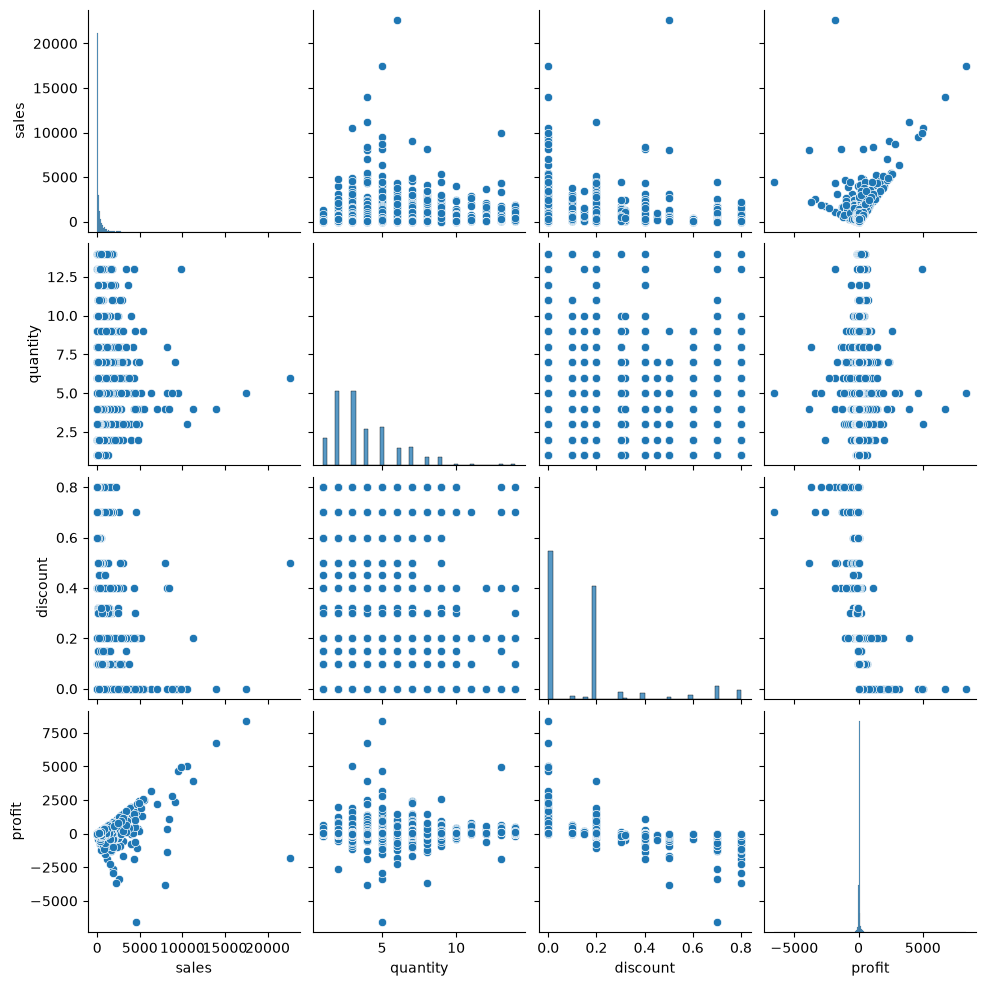

In [97]:
sns.pairplot(df)

## Time-Series Analysis

In [98]:
df.sample()

,order-id,order-date,ship-date,ship-mode,customer-id,customer-name,segment,country,city,state,postal-code,region,product-id,category,sub-category,product-name,sales,quantity,discount,profit
9772,CA-2016-104983,2016-07-03,2016-07-03,Same Day,FM-14215,Filia McAdams,Corporate,United States,Philadelphia,Pennsylvania,19143,East,OFF-PA-10000167,Office Supplies,Paper,Xerox 1925,123.92,5,0.2,38.725


In [99]:
#creating new df for time series analysis bause it needs date time as index!!
#The columns are already in DateTime datatype
dtdf = df.set_index('order-date')
#sorting the dates
dtdf.sort_index(inplace=True)

In [100]:
dtdf.head()

,order-id,ship-date,ship-mode,customer-id,customer-name,segment,country,city,state,postal-code,region,product-id,category,sub-category,product-name,sales,quantity,discount,profit
order-date,,,,,,,,,,,,,,,,,,,
2014-01-03,CA-2014-103800,2014-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
2014-01-04,CA-2014-112326,2014-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
2014-01-04,CA-2014-112326,2014-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
2014-01-04,CA-2014-112326,2014-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2014-01-05,CA-2014-141817,2014-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


### Check time span

In [101]:
dtdf.index.min()

Timestamp('2014-01-03 00:00:00')

In [102]:
dtdf.index.max()

Timestamp('2017-12-30 00:00:00')

The dataset if from date 03/01/2014 to 30/12/2017.  

In [103]:
len(dtdf)

9993

### Check frequency

In this data is daily multiple records.

### Check Missing Dates

In [104]:
perfect_timeline = pd.date_range(start=dtdf.index.min(), end=dtdf.index.max(), freq='D')

In [105]:
missing_dates = perfect_timeline.difference(dtdf.index.unique())

In [106]:
len(missing_dates)

221

### Resample Data

<Axes: xlabel='order-date'>

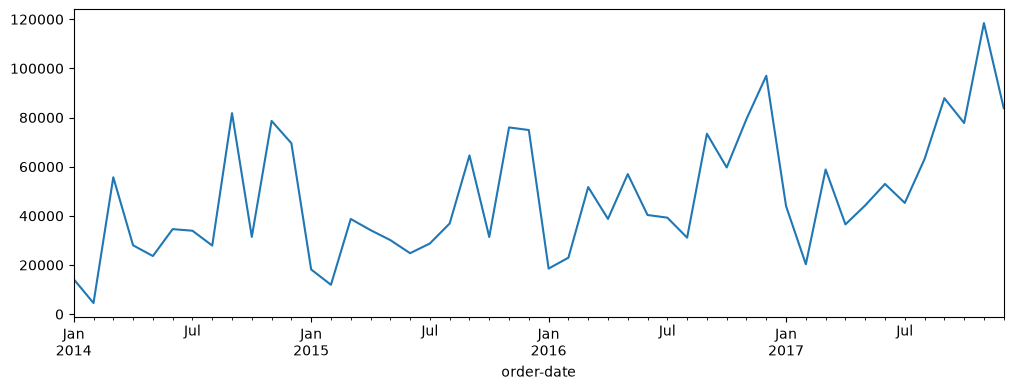

In [107]:
dtdf['sales'].resample('ME').sum().plot(figsize=(12,4))

There are more sales on August, Sept, Oct, Nov and December. But in this specific range that is from August to December there is a lower spike nearly at end of september, but it again get at peak for rest of the range till december.  
The sales are normal at the Jun and July months.  
At the starting of year for 2-3 months sales are high.  

So, overall in the year the Jan is normal at the end of Jan the sales increases and at lasts for 2-3 months again in the Jun and July the graph lowered and after July the sales increases significantly which stays for 4-5 months. In the last 4-5 months at the start of Oct the sales drops but again get increases.

<Axes: xlabel='order-date'>

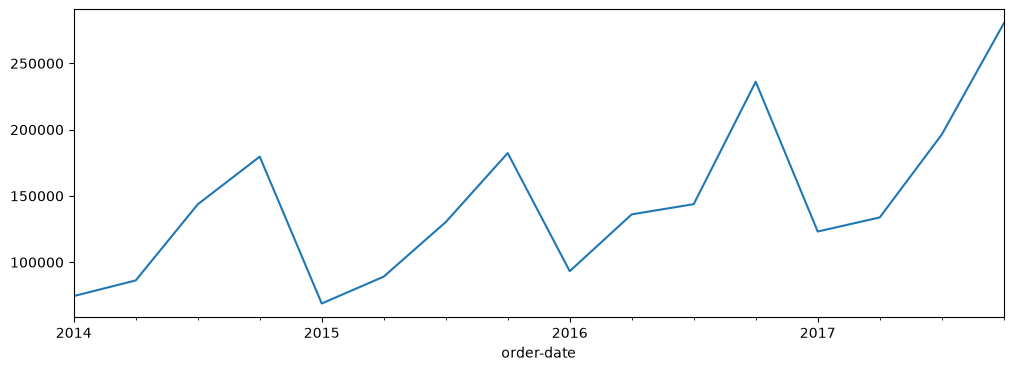

In [108]:
dtdf['sales'].resample('QE').sum().plot(figsize=(12,4))

In the quaterly analysis the year starts with slow increase in sales and gradually reaches at the peak and around end of Q3 or starting of Q4 the sales starts decreasing.

<Axes: xlabel='order-date'>

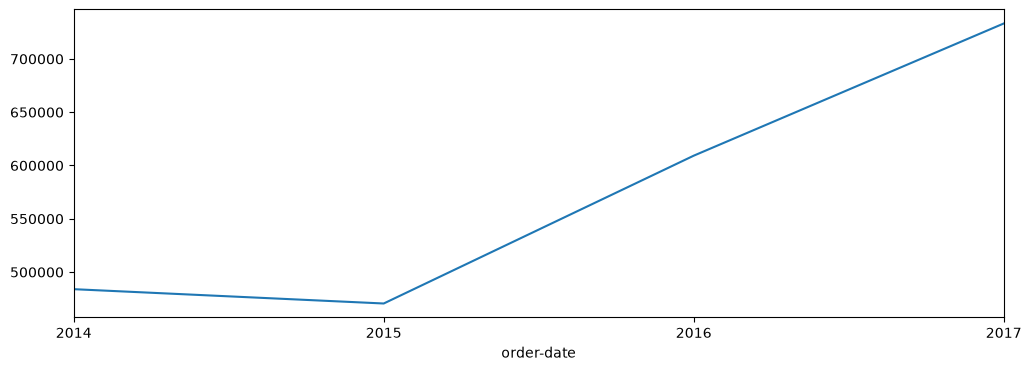

In [109]:
dtdf['sales'].resample('YE').sum().plot(figsize=(12,4))

The 2014 hav the slightly low graph from start to end of the year but from the 2015 the sales are having increased till 2017.

<Axes: title={'center': 'monthly profit average'}, xlabel='order-date'>

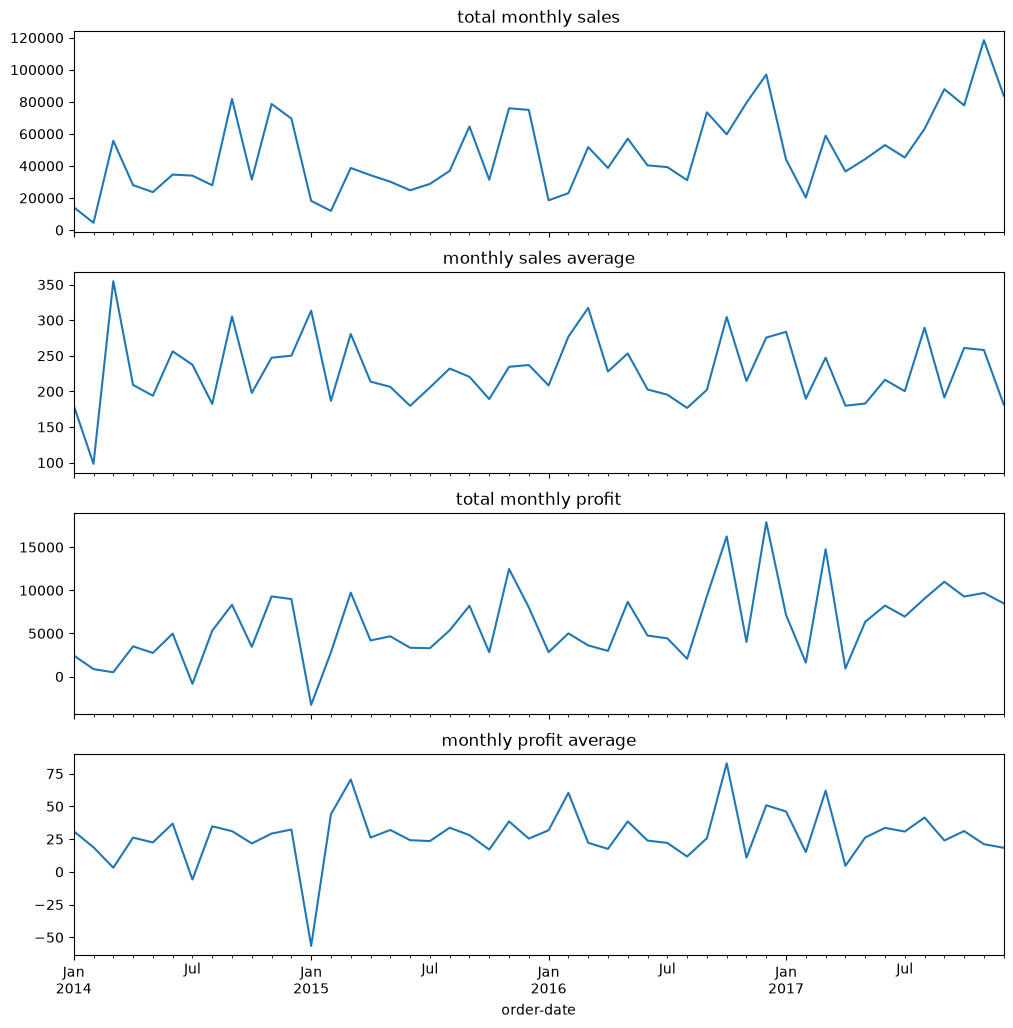

In [110]:
# lets see the total sales and profit together
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 12), sharex=True)
dtdf['sales'].resample('ME').sum().plot(ax=axes[0], title='total monthly sales')
dtdf['sales'].resample('ME').mean().plot(ax=axes[1], title='monthly sales average')
dtdf['profit'].resample('ME').sum().plot(ax=axes[2], title='total monthly profit')
dtdf['profit'].resample('ME').mean().plot(ax=axes[3], title='monthly profit average')

<Axes: title={'center': 'monthly total profit'}, xlabel='order-date'>

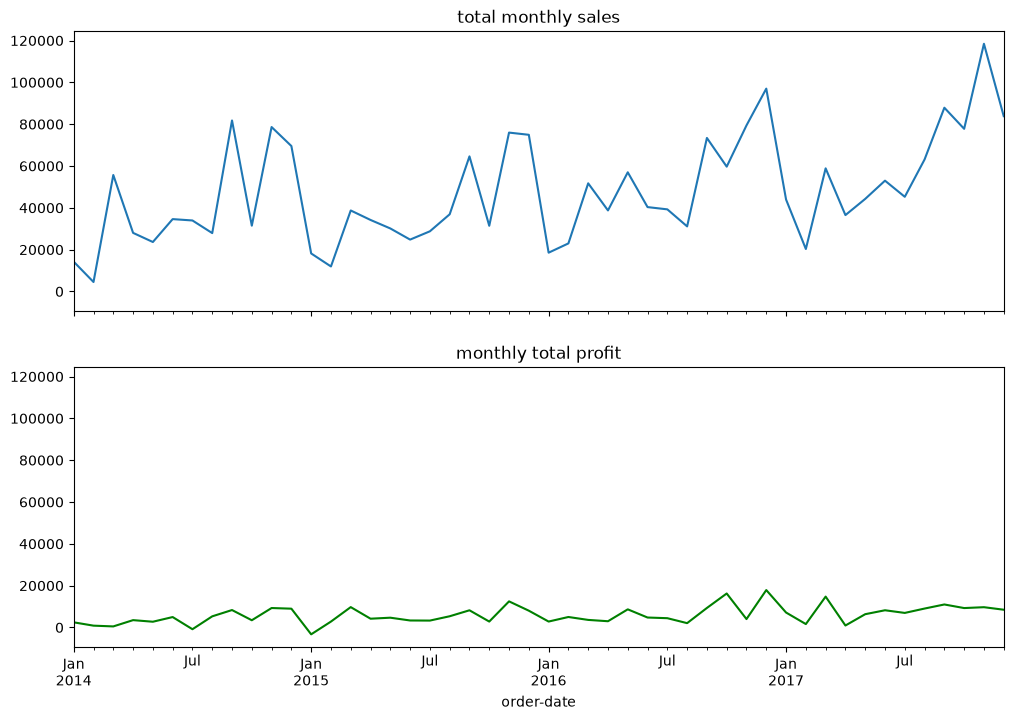

In [111]:
fig, axes = plt.subplots(2,1, figsize=(12, 8), sharex=True, sharey=True)
dtdf['sales'].resample('ME').sum().plot(ax=axes[0], title='total monthly sales')
dtdf['profit'].resample('ME').sum().plot(ax=axes[1], color='green', title='monthly total profit')

Not different though if sales are more then profit also be more butat some points the sales are not more but at that time the profit is significantly more.  
Like starting of year 2015 and 2017 the profit is spiked little bit even though the sales are not increased that much.  
The profit follows sales data. they both are directly proportional!  

<Axes: title={'center': 'number of orders monthly'}, xlabel='order-date'>

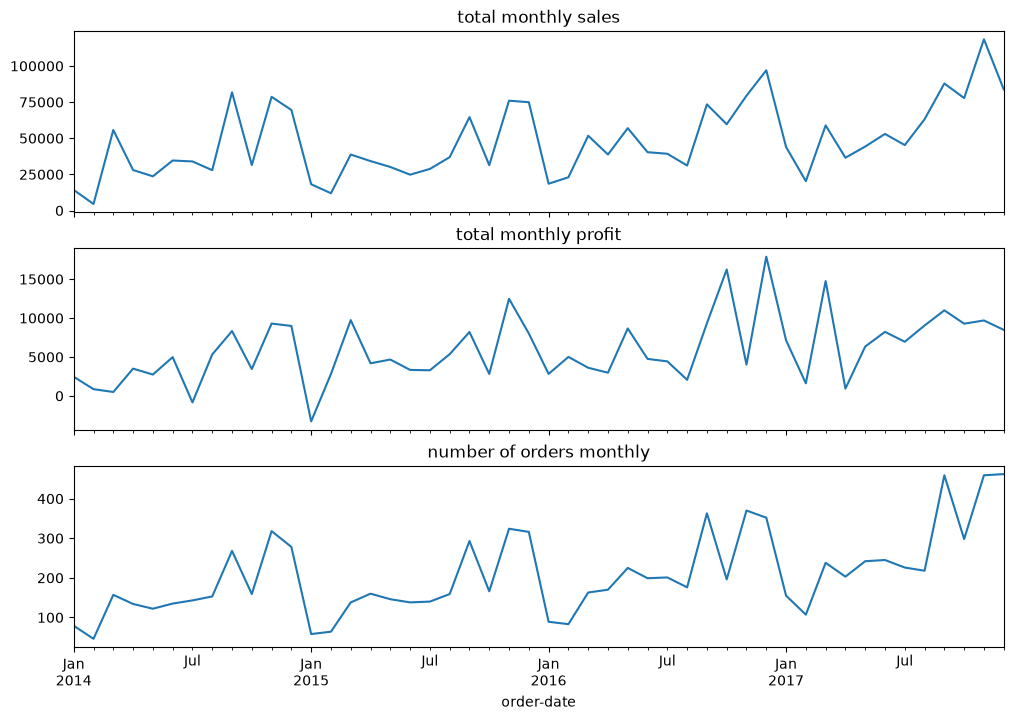

In [112]:
fig, axes = plt.subplots(3,1, figsize=(12, 8), sharex=True)
dtdf['sales'].resample('ME').sum().plot(ax=axes[0], title='total monthly sales')
dtdf['profit'].resample('ME').sum().plot(ax=axes[1], title='total monthly profit')
dtdf['sales'].resample('ME').count().plot(ax=axes[2], title='number of orders monthly')

There is no strange observation in this...  
The count is directly proportional so as count of orders increases the sales also increases.  
The end of 2017 the sales are highest but the profit is not that good as per the count of orders.

<Axes: xlabel='order-date'>

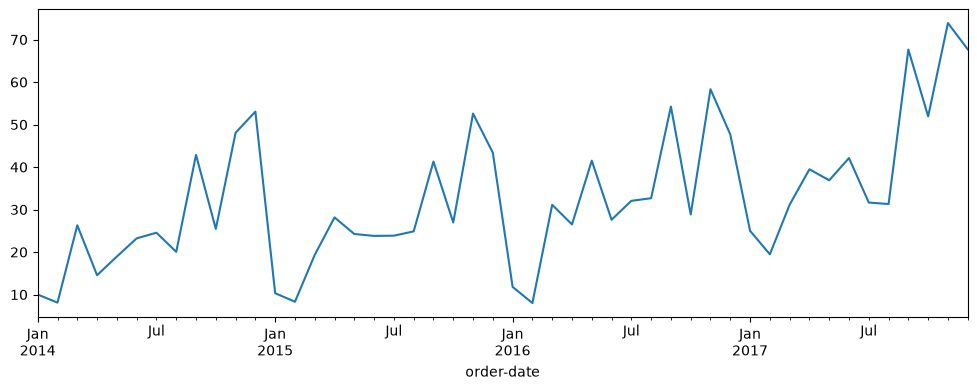

In [113]:
dtdf['discount'].resample('ME').sum().plot(figsize=(12, 4))

In [114]:
lines = ['2014-01-01','2015-01-01','2016-01-01','2017-01-01']

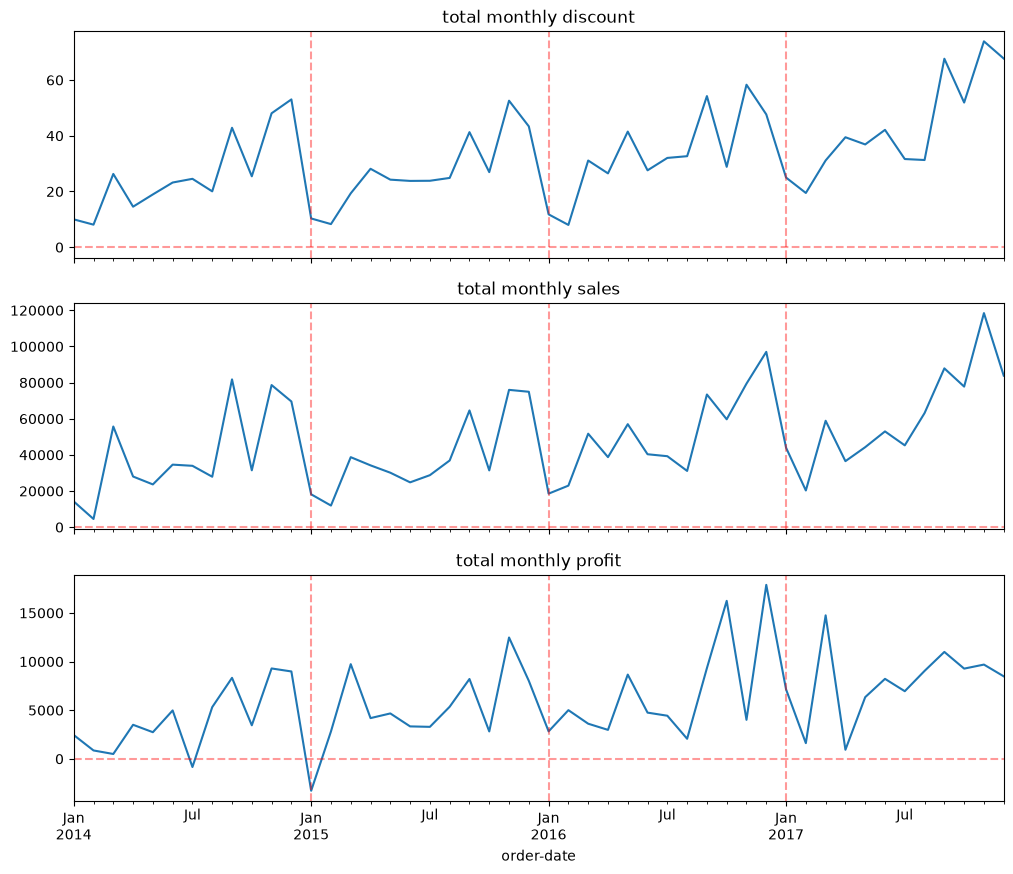

In [115]:
fig, axes = plt.subplots(3,1,figsize=(12, 10), sharex=True)
dtdf['discount'].resample('ME').sum().plot(ax=axes[0], title='total monthly discount')
dtdf['sales'].resample('ME').sum().plot(ax=axes[1], title='total monthly sales')
dtdf['profit'].resample('ME').sum().plot(ax=axes[2], title='total monthly profit')
for ax in axes:
    for date in lines:
        ax.axvline(
            x=pd.to_datetime(date), 
            color='red', 
            linestyle='--', 
            alpha=0.4, 
            linewidth=1.5
        )
for ax in axes:
    ax.axhline(
        y=0, 
        color='red', 
        linestyle='--', 
        alpha=0.4
    )

The sales are more when the discount is there but dispite giving the discount the profit is there.  
At the starting the discount does not work well as compare to after july time, after july the heavy discount have heavy sales with profit.

### Trend analysis

<Axes: xlabel='order-date'>

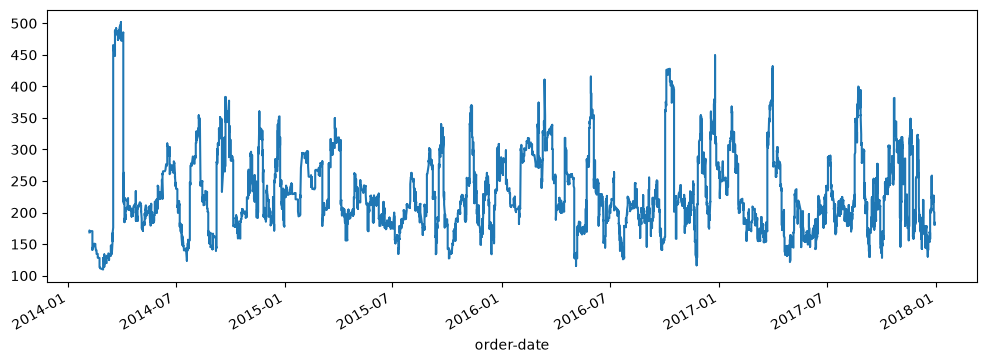

In [116]:
dtdf['sales'].rolling(window=90).mean().plot(figsize=(12,4))

In [117]:
dtdf['month'] = dtdf.index.month

In [118]:
dtdf['year'] = dtdf.index.year

<Axes: title={'center': 'total count for month'}, xlabel='month'>

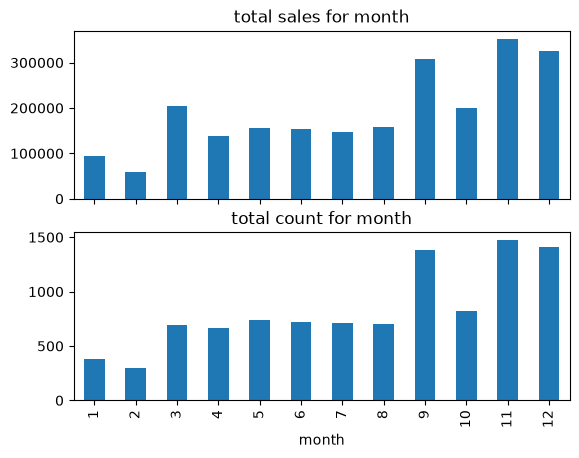

In [119]:
fig, axes = plt.subplots(2, 1, sharex=True)
dtdf.groupby('month')['sales'].sum().plot(kind='bar', ax=axes[0], title='total sales for month')
dtdf.groupby('month')['sales'].count().plot(kind='bar', ax=axes[1], title='total count for month')

So the highest sales happend as the end of the year on 9, 10, 11 and 12th month.

In [120]:
dtdf['sales'].resample('YE').sum()

order-date
2014-12-31    483966.1261
2015-12-31    470532.5090
2016-12-31    609205.5980
2017-12-31    733215.2552
Freq: YE-DEC, Name: sales, dtype: float64

In [121]:
dtdf['sales'].resample('YE').sum() - (dtdf['sales'].resample('YE').sum()).shift(1)

order-date
2014-12-31            NaN
2015-12-31    -13433.6171
2016-12-31    138673.0890
2017-12-31    124009.6572
Freq: YE-DEC, Name: sales, dtype: float64

in the year 2015 the company made less sales as compare to previous year by 13433.  
In the 2016 company made more sales than 2015.  
But in 2017 the sales decreases as compare to 2016.

In [122]:
dtdf['profit'].resample('YE').sum()

order-date
2014-12-31    49556.0329
2015-12-31    61618.6037
2016-12-31    81795.1743
2017-12-31    93439.2696
Freq: YE-DEC, Name: profit, dtype: float64

In [123]:
dtdf['profit'].resample('YE').sum() - (dtdf['profit'].resample('YE').sum()).shift(1)

order-date
2014-12-31           NaN
2015-12-31    12062.5708
2016-12-31    20176.5706
2017-12-31    11644.0953
Freq: YE-DEC, Name: profit, dtype: float64

The company made 12062 more profit than previous year in 2015.  
for 2016 20k more than 2015 profit.  
in 2017 it decreases to 11k.